In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes', 'gymnasium']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact'), 'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Function Approximation in Reinforcement Learning

Tabular methods store separate values or policy parameters for every state. They therefore do not apply directly to continuous state spaces, where an agent may rarely encounter the same state twice. Neural networks replace these tables with functions that generalize across states.

The policy-gradient derivations in that section and that section require only a differentiable policy, a value estimate, and a sampling procedure, so the same training loop can use a neural policy for CartPole and a Gaussian policy for continuous control. We then examine how function approximation couples updates across states and compare score-function and pathwise gradient estimators.

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import gymnasium as gym
import jax
from jax import numpy as jnp
import numpy as np

## Continuous States and Function Approximation

### CartPole

CartPole is the classic small control problem: a cart slides along a track with a pole hinged on top, the state is four real numbers (cart position, cart velocity, pole angle, angular velocity), and the two actions push the cart left or right. Every step the pole stays up earns reward $1$; the episode ends when the pole tips too far, the cart leaves the track, or 500 steps pass. The best possible return is therefore 500. A table over four continuous coordinates does not exist, so $\pi_\theta$ and $\hat{V}$ must become functions.

### Replacing the Table with a Network

The `ActorCritic` interface from that section requires a module that maps a state to one preference per action. The `.tabular` constructor supplies an embedding table; the constructor below instead supplies a one-hidden-layer network with four inputs and two action preferences, plus a value network of the same shape. The softmax in the equation operates on the network outputs as it did on a table row. The score $\nabla_\theta \log \pi_\theta(a \mid s)$ now includes the hidden layer, and automatic differentiation applies the additional chain rule.

In [2]:
@d2l.add_to_class(d2l.ActorCritic)
@classmethod
def mlp(cls, obs_dim, num_actions, hidden=64, lr=1e-2, rngs=None):
    """The same container with the tables replaced by one-hidden-layer nets."""
    rngs = nnx.Rngs(d2l.get_key()) if rngs is None else rngs
    def net(out):
        return nnx.Sequential(nnx.Linear(obs_dim, hidden, rngs=rngs), jnp.tanh,
                              nnx.Linear(hidden, out, rngs=rngs))
    return cls(net(num_actions), net(1), lr)

_act_probs = nnx.jit(lambda net, obs: jax.nn.softmax(net(obs), -1))

@d2l.add_to_class(d2l.ActorCritic)
def act(self, obs, rng):
    """As in :numref:`sec_imitation`; the acting forward has one fixed input
    shape and runs a few hundred thousand times below, so it is compiled
    once and cached (:numref:`sec_compilation`)."""
    if not hasattr(self, '_fwd'):
        self._fwd = nnx.cached_partial(_act_probs, self.policy)
    probs = np.asarray(self._fwd(jnp.asarray(obs)))
    return int(rng.choice(len(probs), p=probs))

The learned baseline of that section must also use function approximation. Equation the equation moved one table entry toward an observed reward-to-go; for a network, the corresponding update minimizes mean squared error against the observed targets. The `num_steps` argument sets the number of critic regression steps per batch. This section uses $1$ step, while that section varies it.

In [3]:
def fit_value(ac, obs, target, num_steps=1):
    """Regress the value head on a fixed target: eq_value_baseline for nets.

    Not jitted: batches change shape at every update; jit would recompile."""
    obs, target = jnp.asarray(obs), jnp.asarray(target)
    for _ in range(num_steps):
        loss, grads = nnx.value_and_grad(
            lambda value: ((ac.V(obs, value) - target) ** 2).mean())(ac.value)
        ac.opt_v.update(ac.value, grads)
    return float(loss)

The training function below is the learned-baseline REINFORCE algorithm from that section. It collects rollouts, computes reward-to-go, subtracts a learned value estimate, updates the policy, and fits the value function. The agent constructor and environment are arguments, allowing the same function to train different policy representations.

We normalize the advantages because the tasks considered below have substantially different return scales; as discussed in that section, this changes the effective step size. The controlled estimator comparison used plain SGD to expose that effect, whereas the neural-network experiments use Adam through the optimizer owned by each policy object.

In [4]:
def train_reinforce(seed, make_agent, env_name, gamma=0.99, num_updates=80,
                    batch_episodes=8):
    """The learned-baseline REINFORCE of :numref:`sec_baselines`, unchanged;
    what varies is the policy object handed in by `make_agent`."""
    rng, env = np.random.default_rng(seed), gym.make(env_name)
    ac = make_agent(seed)
    env.reset(seed=seed)
    for _ in range(num_updates):
        batch = d2l.rollout(env, ac.act, batch_episodes, rng)
        G = batch.reward_to_go(gamma)
        w = d2l.normalize(G - ac.value_np(batch.obs))
        L = d2l.policy_step(ac, batch, w)
        fit_value(ac, batch.obs, G)
        yield float(batch.episode_returns().mean()), L

Relative to that section, three inputs change: the constructor
is `ActorCritic.mlp(4, 2)` instead of `ActorCritic.tabular(16, 4)`, the
environment is `'CartPole-v1'` instead of `'FrozenLake-v1'`, and the
discount is $0.99$, suited to a 500-step horizon, instead of $0.95$. The
rollout, reward-to-go, policy update, and value-regression code remains
unchanged. This compact diagnostic omits the replay, bootstrapped targets,
and update constraints introduced in Chapter 15. We run three seeds:

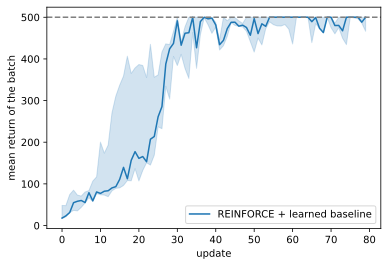

In [5]:
def cartpole_agent(seed):
    return d2l.ActorCritic.mlp(4, 2, rngs=nnx.Rngs(seed))

runs = d2l.run_seeds(train_reinforce, 3, make_agent=cartpole_agent,
                     env_name='CartPole-v1')
d2l.plot_curves({'REINFORCE + learned baseline': runs[:, :, 0]},
                xlabel='update', ylabel='mean return of the batch',
                reference=500)

The untrained policy obtains return about 20. Every seed's per-update batch mean exceeds 400 within approximately fifty updates and remains above 400 through the final update. Variation among seeds in this range makes the overall level more informative than the final digit. The tabular derivation requires no new equation for the network policy.

### Tables as Linear Networks on One-Hot States

`ActorCritic.tabular` stores its preferences in an embedding table. Selecting row $s$ from this table is equivalent to applying a linear layer to the one-hot vector for state $s$. A tabular policy can therefore be viewed as a linear network with fixed one-hot features. These features are orthogonal, so an update at one state does not affect another. A hidden layer learns shared features instead, allowing observations to generalize across states. Shared parameters also introduce nonconvex optimization, extrapolation outside well-sampled regions, and interference between updates; these issues are developed in that section.

## Continuous Actions and Stochastic Policies

### The Gaussian Policy

Pendulum is a simple task with continuous actions. A pendulum hangs from a motorized pivot, the state is $(\cos\vartheta,\sin\vartheta,\dot\vartheta)$, and the action is a torque in $[-2,2]$. Each step gives the negative of an approximate squared angle error, with smaller penalties for angular speed and torque. An episode lasts 200 steps. An uncontrolled policy obtains a return near $-1200$, whereas a controller that swings up and balances obtains about $-200$. Because torque is real valued, a softmax over a finite action set is not applicable.

We use a Gaussian policy $\pi_\theta(a\mid s)=\mathcal{N}(a;\mu_\theta(s),\sigma^2)$. The network produces the mean action, and the log standard deviation is a learned parameter. `GaussianPolicy` subclasses `ActorCritic` and implements the three distribution-specific methods `log_prob`, `act`, and `act_greedy`. The rollout and training functions depend only on this interface and therefore require no changes. The log standard deviation belongs to the policy module so that it is included in the policy update.

In [6]:
class GaussianHead(nnx.Module):
    """Mean network plus a state-independent learned log standard deviation."""
    def __init__(self, obs_dim, act_dim, hidden, rngs):
        self.mean = nnx.Sequential(nnx.Linear(obs_dim, hidden, rngs=rngs),
                                   jnp.tanh,
                                   nnx.Linear(hidden, act_dim, rngs=rngs))
        self.log_std = nnx.Param(jnp.zeros(act_dim))

    def __call__(self, obs):
        return self.mean(obs), jnp.exp(self.log_std[...])

class GaussianPolicy(d2l.ActorCritic):
    """The same interface over a Normal instead of a softmax; nothing that
    consumes the interface changes."""
    def __init__(self, obs_dim, act_dim, hidden=64, lr=1e-2, rngs=None):
        rngs = nnx.Rngs(d2l.get_key()) if rngs is None else rngs
        super().__init__(GaussianHead(obs_dim, act_dim, hidden, rngs),
                         nnx.Sequential(nnx.Linear(obs_dim, hidden, rngs=rngs),
                                        jnp.tanh,
                                        nnx.Linear(hidden, 1, rngs=rngs)), lr)

    def log_prob(self, obs, act, policy=None):
        mean, std = (self.policy if policy is None else policy)(obs)
        return jax.scipy.stats.norm.logpdf(act, mean, std).sum(-1)

    def act(self, obs, rng):
        if not hasattr(self, '_fwd'):   # compile the fixed-shape acting
            self._fwd = nnx.cached_partial(nnx.jit(lambda net, o: net(o)),
                                           self.policy)  # forward, once
        mean, std = self._fwd(jnp.asarray(obs))
        return np.asarray(mean) + np.asarray(std) * rng.standard_normal(
            mean.shape, dtype=np.float32)

    def act_greedy(self, obs, rng=None):
        return np.asarray(self.policy(jnp.asarray(obs))[0])

The environment clips sampled torque to $[-2, 2]$, so `act` can return the unbounded Gaussian draw. Before training, we compare `log_prob` with the analytic Gaussian density, following the softmax-score check in that section. At initialization, $\sigma = e^0 = 1$, so the analytic expression requires only the mean returned by `act_greedy`:

In [7]:
gp = GaussianPolicy(3, 1, rngs=nnx.Rngs(1))
rng = np.random.default_rng(1)
obs = rng.standard_normal((5, 3)).astype(np.float32)
act = rng.standard_normal((5, 1)).astype(np.float32)
mean = np.stack([gp.act_greedy(o) for o in obs])
hand = -0.5 * (act - mean) ** 2 - 0.5 * np.log(2 * np.pi)
print(np.allclose(gp.log_prob_np(obs, act), hand.sum(-1), atol=1e-5))

True


### The Score Function with Continuous Actions

The derivation of the equation requires $\log\pi_\theta$ to be differentiable in $\theta$, but does not require a finite action set. For a Gaussian policy, $\nabla_\theta\log\pi_\theta(a\mid s)$ is available just as it is for a softmax policy, so the same REINFORCE implementation applies.

We train longer because the policy must discover how to swing the pendulum upright before balancing it. We also use $\gamma=0.95$, which shortens the credit-assignment horizon in a 200-step task with a loss at every step. Since the discount factor defines the objective (that section), this choice changes the relative importance of later rewards; it is part of the task specification rather than a variance-reduction parameter:

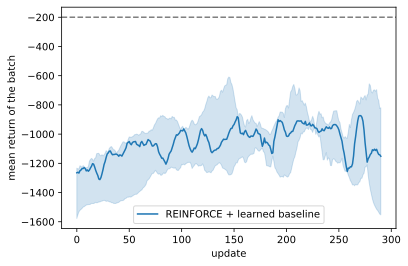

In [8]:
def pendulum_agent(seed):
    return GaussianPolicy(3, 1, rngs=nnx.Rngs(seed))

runs_p = d2l.run_seeds(train_reinforce, 3, make_agent=pendulum_agent,
                       env_name='Pendulum-v1', gamma=0.95, num_updates=300)
d2l.plot_curves({'REINFORCE + learned baseline': runs_p[:, :, 0]},
                xlabel='update', ylabel='mean return of the batch',
                reference=-200, smooth=10)

The initial returns lie between approximately $-1200$ and $-1600$. At their best, the runs reduce this loss by roughly one quarter to three quarters, depending on the seed and framework. No seed reaches the reference level of $-200$, which corresponds to a controller that reliably swings the pendulum upright and holds it there. Performance can also decline later because the fixed step size continues to update an already improved policy.

Thus the experiment demonstrates improvement with a continuous-action policy, not mastery of the task. that section develops a more controlled policy update. A language model has the analogous discrete policy form: it maps a context to a distribution over vocabulary items, as discussed in that section.

### Score-Function versus Pathwise Gradients

An expected value can also be differentiated by reparameterizing its random variable. Consider a single state, a Gaussian policy $a\sim\mathcal{N}(\mu,\sigma^2)$, and a known differentiable reward $Q(a)$. The gradient of $E[Q(a)]$ with respect to $\mu$ has two equivalent forms:

$$\nabla_\mu\, E\big[ Q(a) \big] = E\Big[ Q(a)\, \frac{a - \mu}{\sigma^2} \Big] = E\big[ Q'(\mu + \sigma z) \big], \qquad z \sim \mathcal{N}(0, 1).$$

The first equality is the score-function identity used throughout this chapter. The second substitutes $a = \mu + \sigma z$, placing $\mu$ inside $Q$ rather than the distribution, and differentiates through the sample. This is the *pathwise* or reparameterization gradient [@Kingma.Welling.2014], and the figure illustrates where each estimator's gradient flows. Both are unbiased. They are not equally noisy:

In [9]:
def Q(a):                     # a stand-in critic, differentiable in the action
    return -(a - 1.0) ** 2

sigma, N = 0.5, 100000
a = sigma * np.random.default_rng(2).standard_normal(N, dtype=np.float32)
g_score = Q(a) * a / sigma ** 2               # score-function samples, mu = 0
g_path = np.asarray(jax.vmap(jax.grad(Q))(jnp.asarray(a)))  # per-sample dQ/da
print(f'score:    mean {g_score.mean():.2f}, variance {g_score.var():.1f}')
print(f'pathwise: mean {g_path.mean():.2f}, variance {g_path.var():.2f}')
print(f'score variance if Q gains a constant +10: '
      f'{((Q(a) + 10) * a / sigma ** 2).var():.0f}; pathwise is unchanged')

score:    mean 1.98, variance 21.5
pathwise: mean 2.00, variance 1.00
score variance if Q gains a constant +10: 281; pathwise is unchanged


Both sample means are close to the exact gradient $2.0$, but the score-function variance is about twenty times larger. Adding a constant to $Q$ increases the score-function variance by another order of magnitude, because $Q$ appears as a scalar multiplier. The pathwise estimator is unchanged because it depends on $Q'$ and the derivative of a constant is zero. This lower variance requires access to $Q$ as a differentiable function of the action, rather than only to sampled returns.

![Two estimators of the same gradient. Left: the score-function estimator uses the environment only through the returned reward, so the environment need not be differentiable. Right: the pathwise estimator rewrites the sample as $a = \mu_\theta(s) + \sigma_\theta(s)\,z$ and differentiates through $\partial Q_w / \partial a$ and $\partial a / \partial \theta$. The critic $Q_w$ must be differentiable in the action and can be trained by regression on replayed data, provided the buffer covers states and actions relevant to the current policy.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-score-vs-pathwise.svg)

### The Argmax over Continuous Actions

Value-based methods obtain an action by maximizing $Q(s,a)$. With four discrete actions this is a table lookup. For $a\in\mathbb{R}^d$, however, it becomes a continuous optimization problem that must be solved both when acting and when constructing update targets. The DQN methods in that section therefore retain discrete actions. Policy-gradient methods avoid this explicit maximization by sampling directly from a parameterized policy.

A common continuous-action alternative trains a second network to approximate the maximizing action. A deterministic actor is updated through the learned critic $Q_w(s,a)$ using the pathwise derivative $\partial Q_w/\partial a\cdot\partial a/\partial\theta$ from the figure.

Two independent choices help organize these methods. The first is the gradient estimator: score function or pathwise. The second is the data source: on-policy or off-policy.

Pathwise gradients pair naturally with replayed data because the critic is trained by regression, but the pairing is not required by the mathematics. Importance weighting can adapt a score-function estimator to off-policy data, while a pathwise method still requires its replay buffer to cover relevant states and actions. DDPG and TD3 use deterministic actors; SAC uses a stochastic actor with a reparameterized gradient. In practice, DDPG, TD3, and SAC combine pathwise gradients with replay, whereas REINFORCE, actor--critic, and PPO commonly use score-function gradients with recent on-policy data.

## Generalization across States

### Measuring State Coupling

Networks change how updates generalize across states. A table update changes one row, whereas a network update can change every state because all states share parameters. the figure illustrates this coupling. The following diagnostic raises the estimated value of one state among 256 probes and measures the change at all probes, then repeats the update with a table.

In [10]:
net_probe = d2l.ActorCritic.mlp(4, 2, rngs=nnx.Rngs(0))
tab_probe = d2l.ActorCritic.tabular(16, 4, rngs=nnx.Rngs(0))
S = np.random.default_rng(0).uniform(-1, 1, (256, 4)).astype(np.float32)
before = net_probe.value_np(S)
fit_value(net_probe, S[:1], before[:1] + 1.0, num_steps=25)   # raise ONE state
dV = net_probe.value_np(S) - before
before_t = tab_probe.value_np(np.arange(16))
fit_value(tab_probe, np.arange(1), before_t[:1] + 1.0, num_steps=25)
dV_t = tab_probe.value_np(np.arange(16)) - before_t
print(f'network: nudged state moved {dV[0]:+.2f}; '
      f'{(np.abs(dV[1:]) > 1e-4).sum()} of the 255 others moved too, '
      f'|change| up to {np.abs(dV[1:]).max():.2f}')
print(f'table:   nudged entry moved {dV_t[0]:+.2f}; '
      f'largest move among the other fifteen: {np.abs(dV_t[1:]).max():.6f}')

network: nudged state moved +1.12; 255 of the 255 others moved too, |change| up to 1.20
table:   nudged entry moved +1.18; largest move among the other fifteen: 0.000000


The network update changes the output at all 255 unobserved probe states, sometimes by as much as at the selected state. The tabular update changes only one entry. Function approximation is useful because experience at one continuous state can influence nearby or related states that may never be visited exactly. The same coupling can also reduce performance at states absent from the current batch, which contributes to nonmonotone training curves. With bootstrapped value targets, this interaction becomes an important stability issue in that section.

![What one value update touches. A value estimate over a one-dimensional state is fitted twice, as a sixteen-entry table and as a model with 64 unit-normalized tanh random features, and each takes one gradient step of size $\alpha = 0.5$ toward a target one unit above its estimate at the marked state $x_0$, so the visited state moves by $+0.50$ under both. (a) The table moves one entry and nothing else. (b) The model moves its entire curve, because every state's estimate shares parameters with $x_0$'s. (c) The two changes side by side: the model's update is still $+0.40$ at the far end of the state space and nowhere less than $+0.33$.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-table-vs-network.svg)

### Policy Gradients with Function Approximation

A policy-gradient update estimates the gradient of the scalar objective $J(\theta)$ in the equation. Under the usual assumptions of smoothness, bounded-variance unbiased gradients, and decaying step sizes, this has the form studied in stochastic optimization. The implementation here does not satisfy all of those assumptions: normalization rescales each batch using its data, samples depend on the collecting policy, and Adam uses a fixed step size. The curves should therefore be interpreted as empirical results rather than applications of a convergence theorem.

The value network in this section is fitted to observed reward-to-go targets that do not depend on the network's own predictions. Bootstrapped value methods instead construct targets from the current value estimate. Although each update is a gradient step with its target held fixed, the expected semi-gradient field need not be the gradient of a single scalar objective, and function approximation can make the iteration diverge [@Tsitsiklis.VanRoy.1997]. Residual-gradient methods optimize a Bellman-error objective directly but encounter the double-sampling problem from that section.

Bootstrapped critics and their stability are introduced in that section and that section.

## The Surrogate Loss

Deep learning frameworks express updates through scalar losses. Instead of assembling the estimator $\hat{u}$ from that section explicitly, we define

$$L(\theta) = -\frac{1}{N} \sum_{\textrm{steps}} \hat{A}_t\, \log \pi_\theta(a_t \mid s_t),$$

where the advantages $\hat A_t$ are treated as fixed. Its gradient is $-\hat u$ up to the positive batch-normalization factor discussed in that section, so minimizing $L$ implements a policy-gradient ascent step. In `policy_step`, the advantages arrive as a NumPy array and therefore carry no gradient graph. The numerical value of this surrogate loss is not an estimate of policy performance: it is constructed to have the desired derivative at the current parameters. Consequently, a decrease in $L$ need not correspond to an increase in return. The CartPole runs record both quantities:

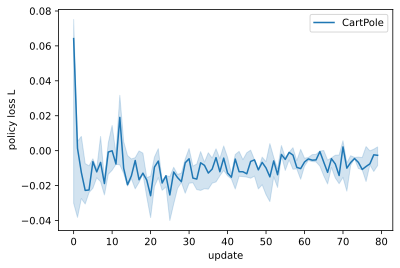

In [11]:
d2l.plot_curves({'CartPole': runs[:, :, 1]}, xlabel='update',
                ylabel='policy loss L')

The return increases substantially, but the policy loss fluctuates near zero without a consistent trend across seeds. This is expected because the normalized advantages have zero sample mean and the loss records their current correlation with the log-probabilities. Its gradient defines the update, but its numerical value is not a measure of policy quality. Return and update diagnostics such as probability ratios, divergences, and entropy are more informative.

The resulting agent still has three important limitations. It waits for complete episodes before updating because the critic uses reward-to-go targets; that section introduces bootstrapping for earlier updates. It uses each on-policy batch for a single policy step; that section studies controlled batch reuse, while that section uses a replay buffer. Finally, the algorithm does not constrain the size of a policy update, even though a large change can degrade both current performance and subsequent data collection. These topics motivate that section.

## Summary

Tabular representations cannot cover continuous state spaces, whereas neural networks share parameters and generalize across states. `ActorCritic.mlp` replaces the tabular embedding with a one-hidden-layer network, and `fit_value` expresses the value-baseline update as regression. The same learned-baseline REINFORCE loop trains CartPole, and a Gaussian policy extends it to continuous actions on Pendulum. Score-function and pathwise estimators compute the same gradient with different variances and assumptions. This choice is separate from whether training uses on-policy or off-policy data, although pathwise gradients commonly appear with replay in DDPG, TD3, and SAC.

Parameter sharing makes continuous problems learnable but also couples updates across states. The next chapter introduces bootstrapped critics, batch reuse, replay, and constraints on policy updates.

**Experimental scope.** CartPole and Pendulum use three seeds per framework, so the curves support broad trends rather than precise numerical comparisons. CartPole is solved reliably, whereas Pendulum improves without approaching its maximum return. The coupling and gradient-variance examples are deterministic probes; the measured variance ratio depends on the chosen function, policy spread, and offset.

## Exercises

1. [conceptual] *A surrogate loss is not a performance metric.* Show that the gradient of
   the equation equals $-\hat{u}$ up to a positive constant
   when the advantages are held fixed. Then describe a situation in which the
   value of that loss decreases while the return also decreases, and say what
   you should plot instead.
1. [short-code] *How small can the policy be.* Sweep the hidden width over
   $\{4, 16, 64\}$, two seeds each, and report the mean return over the last
   ten updates. How small can the network be and still balance the pole, and
   what changes about the speed and the smoothness of training at each end?
   (About ten minutes on a laptop CPU.)
1. [short-code] *Which return to plot.* `train_reinforce` reports the
   *undiscounted* episode return but uses discounted reward-to-go inside the
   update. Add the discounted return to the plot. Why do the two tell the same
   story here, and construct a task where they would not.
1. [short-code] *Batch size at a fixed episode budget.* Sweep the batch size
   over $\{1, 8, 32\}$ with the total number of sampled episodes held fixed, so
   that smaller batches take proportionally more updates. Which end learns
   fastest per episode, and which gives the smoothest curve? Which of the two
   would you optimize if episodes were expensive?
1. [short-code] *Advantage scale.* Replace the normalized advantage in
   `train_reinforce` by the raw reward-to-go, as in
   that section, and rerun both tasks. Which of the two tasks
   degrades more, and why? (Compare the typical magnitude of $\hat{G}_t$ on
   CartPole and on Pendulum, and recall which optimizer the policy uses.)
1. [conceptual] *Benefits and costs of generalization.* On FrozenLake an update
   touched one row of a table. Here it moves the policy at every state at
   once. Argue why a batch dominated by near-vertical-pole states can make the
   policy *worse* at large pole angles, and name two phenomena in
   that section that are consequences of the same coupling.
1. [short-code] *What the spread costs.* Fix the Gaussian head's `log_std`
   (delete the parameter and hard-code $\sigma$) at each of
   $\sigma \in \{0.1, 1.0, 4.0\}$ and rerun Pendulum with two seeds each. What
   does an over-small $\sigma$ cost, and what does an over-large one cost?
   Relate the two failures to exploration and to the score's variance in
   the equation, and note what the environment's torque clip
   at $\pm 2$ does to the largest choice.

[Discussions](https://d2l.discourse.group/)